# Tutorials for nonlinear theoretical predictions for the spectroscopic observables
## Galaxy power spectrum multipoles from PyBird

__Warning__: to run this part of the notebook it is necessary to first install PyBird: 
```
pip install --no-binary pybird-lss pybird-lss
```
See also [https://github.com/pierrexyz/pybird](https://github.com/pierrexyz/pybird)

In [21]:
# General imports
import numpy as np
import matplotlib.pyplot as plt

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.observables.PyBird_spectro import PyBirdSpectroPower

from cloelib.summary_statistics.legendre_multipoles import LegendreMultipoles

# Avoid warnings for cleaner output 
np.seterr(divide='ignore', over='ignore', invalid='ignore') # Ignore divide by zero and overflow errors in numpy operations, which can occur in loglike calculation, it is annoying otherwise

# Plot style
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

### Define background cosmology, fiducial background, and instantiate background and linear perturbations modules

In [2]:
zeff = 1.

In [3]:
H0_fid = 67.7
Omega_cdm0_fid = 0.27
Omega_b0 = 0.049
Omega_k0 = 0.0
w0 = -1.0
wa = 0.0
ns = 0.96
As = 2.1e-9
gamma_MG = 0.545
mnu = 0.0
N_mnu = 0

background_fiducial = CAMBBackground(
    H0=H0_fid, Omega_cdm0=Omega_cdm0_fid, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu, N_mnu=N_mnu
)

Omega_cdm0 = 0.28
H0 = 70.0

background = CAMBBackground(
    H0=H0, Omega_cdm0=Omega_cdm0, Omega_b0=Omega_b0, Omega_k0=Omega_k0,
    w0=w0, wa=wa, ns=ns, As=As, gamma_MG=gamma_MG, mnu=mnu, N_mnu=N_mnu
)

perturbations = CAMBLinearPerturbations(background=background, redshifts=np.array([zeff]))

Note: redshifts have been re-sorted (earliest first)


Then we pick a redshift, create a dictionary with nuisance (bias and counterterm) parameters for PyBird and create an instance of `PyBirdSpectroPower`, which contains $P(k,\mu)$.

In [14]:
eft_parameters = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bG3': 0.323,
 'c0': 3.1, 'c2': 4.6, 'c4': 11., 'ck4': 0.0
}

pkmu_pybird = PyBirdSpectroPower(linear_perturbations=perturbations, nuisance_parameters=eft_parameters)                            

We create a dictionary with noise and systematic parameters, and create an instance of `LegendreMultipoles` based on `pkmu_pybird`, the noise and systematics parameters. We also need to specify a value for the number density  $\bar{n}$ and a fiducial background cosmology (used to apply Alcock-Paczinsky distortions)

In [16]:
noise_syst_parameters = {
 'NP0': 1.056, 'NP20': 0.0, 'NP22': 0.0,
 'fout': 0.0, 'sigmaz': 0.0
}
mps_pybird = LegendreMultipoles(pkmu_pybird, background_fiducial, noise_syst_parameters, nbar=1e-4)

Finally we use the `power_multipoles` method of the `LegendreMultipoles` instance to get multipoles. By using the flag `use_AP=False` we can also get multipoles without AP distortions, 

In [17]:
dk = 0.005
k = np.arange(0.001, 0.3, dk)
pell_pybird = mps_pybird.power_multipoles(k=k, ells=[0,2,4])
# without AP
pell_pybird_noAP = mps_pybird.power_multipoles(k=k, ells=[0,2,4], use_AP=False)

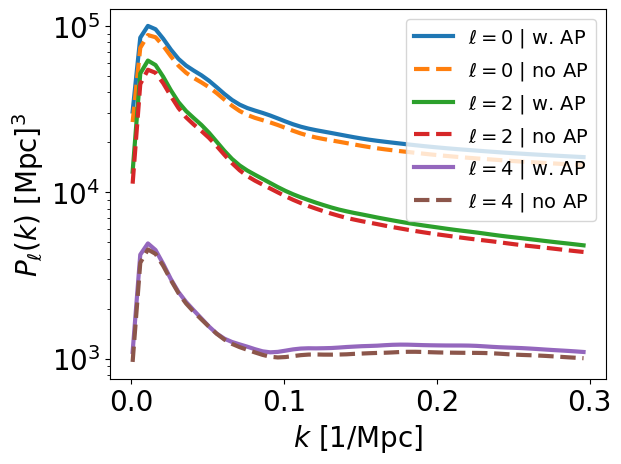

In [18]:
# Impact of AP distortions
for l in [0, 2, 4]:
    plt.plot(k, pell_pybird['ell%s' % l], label=r"$\ell=%s$ | w. AP" % l)
    plt.plot(k, pell_pybird_noAP['ell%s' % l], '--', label=r"$\ell=%s$ | no AP" % l)
plt.xlabel(r'$k \ [1/{\rm Mpc}]$')
plt.ylabel(r'$P_\ell(k)  \ [{\rm Mpc}]^3$')
plt.yscale('log')
plt.legend()

### Pybird vs. PBJ comparison

In [19]:
from cloelib.observables.PBJ_spectro import PBJSpectroPower

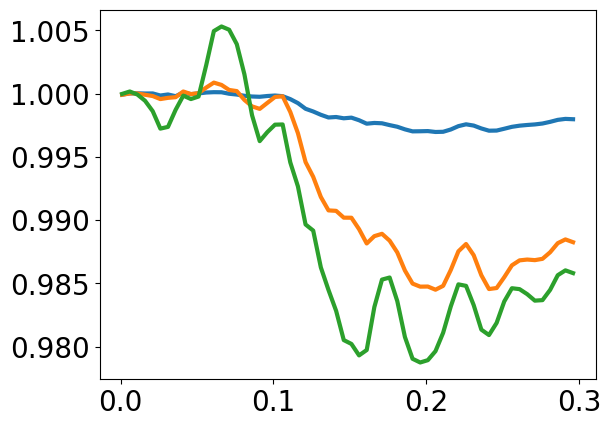

In [20]:
eft_parameters = {
 'b1': 1.412, 'b2': 0.695, 'bG2': -0.156, 'bG3': 0.323,
 'c0': 3.1, 'c2': 4.6, 'c4': 11., 'ck4': 0.0
}

pkmu_pybird = PyBirdSpectroPower(linear_perturbations=perturbations, nuisance_parameters=eft_parameters)     
mps_pybird = LegendreMultipoles(pkmu_pybird, background_fiducial, noise_syst_parameters, nbar=1e-4)      
pell_pybird = mps_pybird.power_multipoles(k=k, ells=[0,2,4])             

pkmu_pbj = PBJSpectroPower(perturbations, eft_parameters) # Notice this needs a LinearPerturbation as input
mps_pbj = LegendreMultipoles(pkmu_pbj, background_fiducial, noise_syst_parameters, nbar=1e-4)
pell_pbj = mps_pbj.power_multipoles(k=k, ells=[0,2,4])

for i, l in enumerate([0, 2, 4]): 
    plt.plot(k, pell_pybird['ell%s' % l]/pell_pbj['ell%s' % l])

The residual difference seen above stems from the IR-resummation scheme.  
One can check that turning off the resummation in both leads to <0.2% difference. 